# Customer Sales Analytics Dashboard - Analysis Notebook

This notebook supports the capstone project by showing the analysis process in Jupyter Notebook.

The main project code is stored in separate Python files, but this notebook brings the project together by running the pipeline, previewing outputs, explaining the analysis, showing basic statistics, and reflecting on the results.

The original dataset used in the project is:

`customer_segmentation_data.csv`

The final project output is a Streamlit dashboard supported by Tableau visualisations and Python analysis.

## Notebook Purpose

This notebook is not meant to replace the Python files.

Instead, it is used to provide clear Jupyter Notebook evidence for the project. It shows:

- how the project pipeline can be run
- how the raw and processed data can be inspected
- how sales, customer, and regression outputs can be reviewed
- how the main findings connect back to the business questions
- how limitations, AI assistance, and improvements were considered

The detailed project code is stored in:

- `main.py`
- `sales_report.py`
- `k-means_clustering.py`
- `regression_model.py`
- `streamlit_gui.py`

## Business Questions

The project was designed around the following business questions:

- How much revenue did the business generate?
- How much revenue was lost through cancellations?
- Are sales increasing or decreasing over time?
- Which countries generate the most completed revenue?
- Which products generate the most completed revenue?
- Which customer groups are most valuable?
- Can previous customer behaviour help predict future order value?
- How can customer and invoice-level data be explored in an interactive dashboard?

In [34]:
from pathlib import Path
import subprocess
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

PROJECT_ROOT = Path.cwd()
print("Project root:", PROJECT_ROOT)

Project root: C:\Capstone_Project_CI


## Check Required Project Files

This cell checks that the notebook is in the correct project folder.

It expects to be beside the main Python files and the original dataset.

In [35]:
required_files = [
    "customer_segmentation_data.csv",
    "main.py",
    "sales_report.py",
    "k-means_clustering.py",
    "regression_model.py"
]

missing_files = []

for file_name in required_files:
    file_path = PROJECT_ROOT / file_name
    if file_path.exists():
        print(f"Found: {file_name}")
    else:
        print(f"Missing: {file_name}")
        missing_files.append(file_name)

if missing_files:
    print("\nSome files are missing. Make sure this notebook is saved in the main project folder.")
else:
    print("\nAll required files were found.")

Found: customer_segmentation_data.csv
Found: main.py
Found: sales_report.py
Found: k-means_clustering.py
Found: regression_model.py

All required files were found.


## Optional: Run the Full Python Pipeline

The main analysis is written in Python scripts. This cell runs the project scripts in order.

If the processed CSV files already exist, this step can be skipped.

**Important:** If `main.py` fails because `completed_purchase_orders.csv` does not exist yet, create completed purchases first or adjust `main.py` so that `completed_purchases()` is called before reading `completed_purchase_orders.csv`.

In [36]:
def run_script(script_name, stop_on_error=True):
    script_path = PROJECT_ROOT / script_name

    if not script_path.exists():
        print(f"Cannot run {script_name}: file not found.")
        return None

    print("=" * 80)
    print(f"Running {script_name}")
    print("=" * 80)

    result = subprocess.run(
        [sys.executable, str(script_path)],
        cwd=PROJECT_ROOT,
        capture_output=True,
        text=True
    )

    if result.stdout:
        print(result.stdout)

    if result.stderr:
        print("Errors / warnings:")
        print(result.stderr)

    if result.returncode != 0:
        print(f"{script_name} finished with error code: {result.returncode}")
        if stop_on_error:
            raise RuntimeError(f"{script_name} failed. Fix the error above before continuing.")
    else:
        print(f"{script_name} completed successfully.")

    return result


scripts_in_order = [
    "main.py",
    "sales_report.py",
    "k-means_clustering.py",
    "regression_model.py"
]

for script in scripts_in_order:
    run_script(script, stop_on_error=True)

Running main.py
Creating customer sales dataset...
   CustomerID  Frequency  ...  AverageOrderValue  TotalQuantity
0       12347          7  ...             615.71           2458
1       12348          4  ...             449.31           2341
2       12349          1  ...            1757.55            631
3       12350          1  ...             334.40            197
4       12352          7  ...             340.82            473

[5 rows x 6 columns]
customer_order_sales_data.csv has been created.
Welcome to Customer Data
       CustomerID  InvoiceNo  ... AverageOrderValue Country
10510       12347     537626  ...            711.79      17
10511       12347     537626  ...            711.79      17
10512       12347     537626  ...            711.79      17
10513       12347     537626  ...            711.79      17
10514       12347     537626  ...            711.79      17

[5 rows x 12 columns]
customer_sales_data.csv has been created.
Creating regression dataset...
This is your d

## Dataset Overview

The first step is to inspect the original dataset.

The original file is loaded using `cp1252` encoding because the dataset did not load correctly with the default encoding during development.

In [37]:
raw_data_path = PROJECT_ROOT / "customer_segmentation_data.csv"

if raw_data_path.exists():
    raw_data = pd.read_csv(raw_data_path, encoding="cp1252")
    display(raw_data.head())
    print("Rows:", raw_data.shape[0])
    print("Columns:", raw_data.shape[1])
else:
    print("Raw dataset not found.")

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


Rows: 541909
Columns: 8


## Missing Values

Missing values were checked because they affect the reliability of the analysis.

Rows with missing `CustomerID` values were removed during cleaning because customer-level features such as frequency, recency, monetary value, and regression behaviour depend on having a valid customer identifier.

Missing product descriptions were filled with `Unknown` so the rows could still be used for sales analysis.

In [38]:
if raw_data_path.exists():
    missing_values = raw_data.isnull().sum().sort_values(ascending=False)
    display(missing_values)
else:
    print("Raw dataset not found.")

CustomerID     135080
Description      1454
StockCode           0
InvoiceNo           0
Quantity            0
InvoiceDate         0
UnitPrice           0
Country             0
dtype: int64

## Basic Statistics

This section gives simple descriptive statistics for the raw numeric columns.

These statistics help understand the range of the data before deeper analysis. For example, `Quantity` and `UnitPrice` can reveal unusual values, cancelled orders, negative quantities, or very large purchases.

In [39]:
if raw_data_path.exists():
    display(raw_data.describe())
else:
    print("Raw dataset not found.")

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


## Data Cleaning Summary

The main cleaning steps were handled in `main.py`.

The cleaning process included:

- loading the original `customer_segmentation_data.csv` file
- filling missing product descriptions with `Unknown`
- removing rows with missing `CustomerID`
- separating normal purchase orders from cancelled orders
- treating invoice numbers beginning with `C` as cancelled orders
- removing invalid purchase rows where `Quantity` or `UnitPrice` were not positive
- creating row-level revenue using `Quantity * UnitPrice`
- creating completed purchase data
- creating customer-level and regression-ready datasets

This cleaning was important because using the raw data directly would have made sales and customer analysis unreliable.

## Check Generated Output Files

The Python files create several processed CSV files.

These files are used by Tableau, Streamlit, customer segmentation, and regression modelling.

In [40]:
expected_outputs = [
    "purchase_orders.csv",
    "cancelled_orders.csv",
    "completed_purchase_orders.csv",
    "matched_reversed_invoices.csv",
    "customer_order_sales_data.csv",
    "customer_sales_data.csv",
    "customer_regression_data.csv",
    "tableau_data/revenue_summary.csv",
    "tableau_data/monthly_sales_and_cancellations.csv",
    "tableau_data/country_revenue.csv",
    "tableau_data/product_revenue.csv",
    "tableau_data/regression_predictions.csv",
    "tableau_data/regression_metrics.csv"
]

for file_name in expected_outputs:
    file_path = PROJECT_ROOT / file_name
    if file_path.exists():
        print(f"Created: {file_name}")
    else:
        print(f"Not found: {file_name}")

Created: purchase_orders.csv
Created: cancelled_orders.csv
Created: completed_purchase_orders.csv
Created: matched_reversed_invoices.csv
Created: customer_order_sales_data.csv
Created: customer_sales_data.csv
Created: customer_regression_data.csv
Created: tableau_data/revenue_summary.csv
Created: tableau_data/monthly_sales_and_cancellations.csv
Created: tableau_data/country_revenue.csv
Created: tableau_data/product_revenue.csv
Created: tableau_data/regression_predictions.csv
Created: tableau_data/regression_metrics.csv


## Revenue Summary

The sales report outputs the main revenue metrics to `tableau_data/revenue_summary.csv`.

This file is used for dashboard KPI cards and helps compare gross purchase revenue, cancellation loss, net revenue, and average invoice values.

In [41]:
revenue_summary_path = PROJECT_ROOT / "tableau_data/revenue_summary.csv"

if revenue_summary_path.exists():
    revenue_summary = pd.read_csv(revenue_summary_path)
    display(revenue_summary)
else:
    print("revenue_summary.csv not found. Run the pipeline first.")

,Metric,Value
0,Gross Purchase Revenue,8911407.90
1,Revenue Lost Through Cancellations,611342.09
2,Net Revenue,8300065.81
3,Average Recorded Purchase Invoice Value,480.87
4,Average Cancelled Invoice Value,167.31
5,Average Completed Purchase Invoice Value,464.75
6,Total Invoices,22186.00
7,Net Average Invoice Value,374.11
8,Largest Completed Purchase Invoice,31698.16
9,Smallest Completed Purchase Invoice,0.38


## Sales Trend Analysis

Monthly completed revenue and cancellation value were analysed to understand whether the business was growing or declining over time.

The final incomplete month was excluded in the project because it created a misleading drop in the trend.

The project found that completed revenue increased strongly over the analysed period, while cancellations caused revenue loss but did not stop the overall positive trend.

,Month,CompletedRevenue,CompletedInvoices,CompletedAverageInvoiceValue,CancellationValue,CancelledInvoices,CancelledAverageInvoiceValue
0,2010-12-01,560568.68,1389,403.58,18109.87,308,58.80
1,2011-01-01,485688.61,976,497.63,94370.66,249,379.00
2,2011-02-01,446590.99,992,450.19,10591.20,204,51.92
3,2011-03-01,588401.77,1305,450.88,15536.15,298,52.13
4,2011-04-01,462796.32,1139,406.32,43152.51,235,183.63


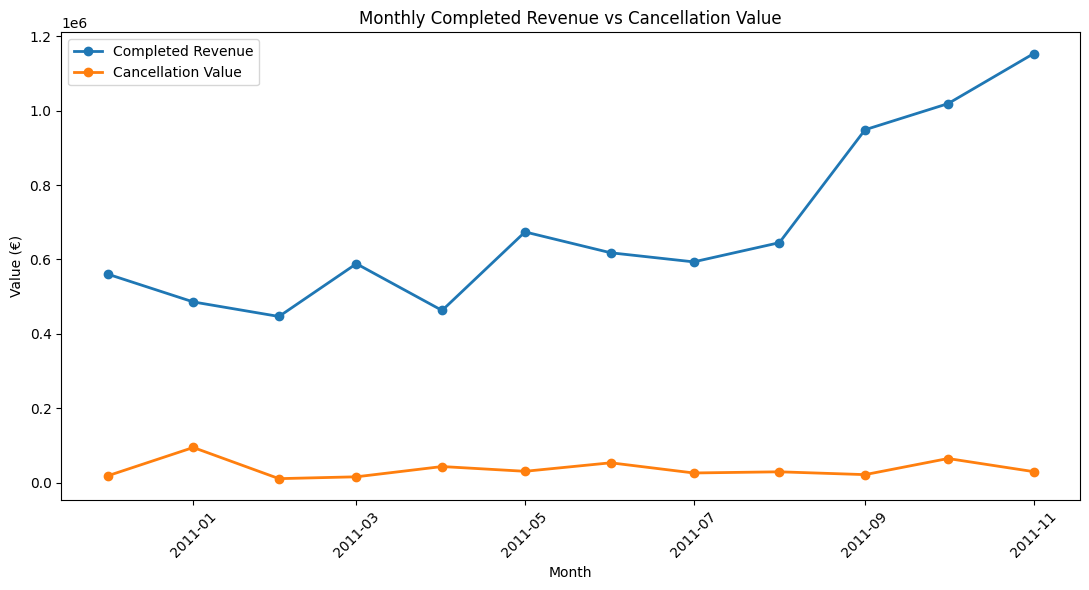

In [42]:
monthly_sales_path = PROJECT_ROOT / "tableau_data/monthly_sales_and_cancellations.csv"

if monthly_sales_path.exists():
    monthly_sales = pd.read_csv(monthly_sales_path)

    monthly_sales["Month"] = pd.to_datetime(monthly_sales["Month"])
    monthly_sales = monthly_sales.sort_values("Month").copy()

    display(monthly_sales.head())

    plt.figure(figsize=(11, 6))

    plt.plot(
        monthly_sales["Month"],
        monthly_sales["CompletedRevenue"],
        marker="o",
        linewidth=2,
        label="Completed Revenue"
    )

    plt.plot(
        monthly_sales["Month"],
        monthly_sales["CancellationValue"],
        marker="o",
        linewidth=2,
        label="Cancellation Value"
    )

    plt.title("Monthly Completed Revenue vs Cancellation Value")
    plt.xlabel("Month")
    plt.ylabel("Value (€)")
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

else:
    print("monthly_sales_and_cancellations.csv not found. Run the pipeline first.")

## Country Revenue Analysis

Country revenue was analysed to identify which countries generated the most completed sales.

This helps answer where the business is strongest. In this dataset, the United Kingdom generated most of the completed revenue, which is useful as a finding but also a limitation because the country analysis is heavily influenced by one dominant country.

,Country,CompletedRevenue,TotalInvoices,TotalCustomers,AverageInvoiceValue
0,36,6966486.11,16529,3912,421.47
1,24,285446.34,94,9,3036.66
2,10,260487.94,257,3,1013.57
3,14,228254.71,455,94,501.66
4,13,207110.29,386,87,536.56
5,0,138219.71,54,9,2559.62
6,31,56332.92,88,29,640.15
7,33,56264.95,50,21,1125.30
8,3,41196.34,98,25,420.37
9,32,38140.33,35,8,1089.72


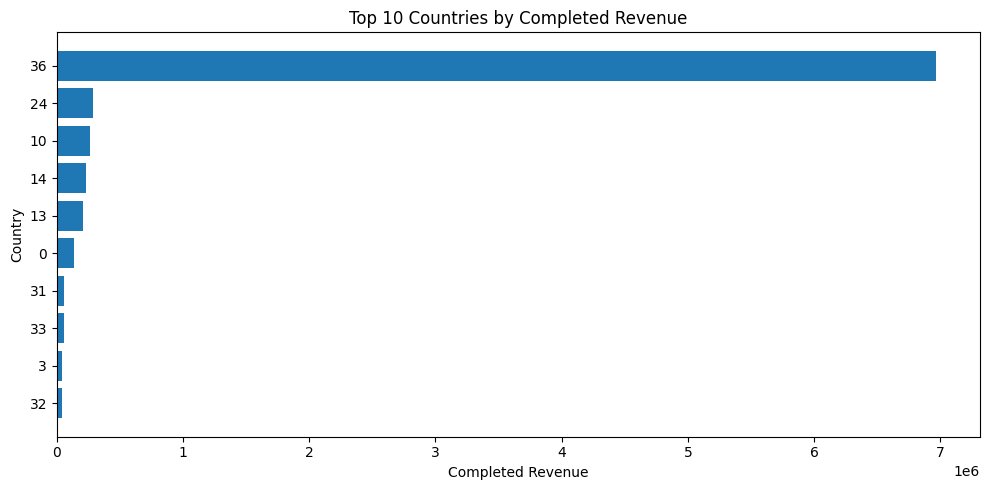

In [43]:
country_revenue_path = PROJECT_ROOT / "tableau_data/country_revenue.csv"

if country_revenue_path.exists():
    country_revenue = pd.read_csv(country_revenue_path)
    display(country_revenue.head(10))

    top_countries = country_revenue.head(10)
    plt.figure(figsize=(10, 5))
    plt.barh(top_countries["Country"].astype(str), top_countries["CompletedRevenue"])
    plt.title("Top 10 Countries by Completed Revenue")
    plt.xlabel("Completed Revenue")
    plt.ylabel("Country")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print("country_revenue.csv not found. Run the pipeline first.")

## Product Revenue Analysis

Product revenue was analysed to identify which products contributed most to completed sales.

This could support stock planning, product promotion, and business decision-making.

,StockCode,Description,CompletedRevenue,TotalQuantitySold,TotalInvoices,TotalCustomers,AverageInvoiceValue
0,22423,REGENCY CAKESTAND 3 TIER,138971.80,12081,1689,877,82.28
1,85123A,WHITE HANGING HEART T-LIGHT HOLDER,98872.25,36123,1962,856,50.39
2,85099B,JUMBO BAG RED RETROSPOT,83882.80,45420,1592,633,52.69
3,POST,POSTAGE,77567.96,3108,1096,331,70.77
4,47566,PARTY BUNTING,68287.28,15162,1373,708,49.74
5,84879,ASSORTED COLOUR BIRD ORNAMENT,56517.81,35325,1371,676,41.22
6,23084,RABBIT NIGHT LIGHT,51308.76,27184,799,449,64.22
7,M,Manual,45934.29,7159,244,195,188.26
8,79321,CHILLI LIGHTS,45193.51,9374,516,204,87.58
9,22086,PAPER CHAIN KIT 50'S CHRISTMAS,41637.88,15216,973,612,42.79


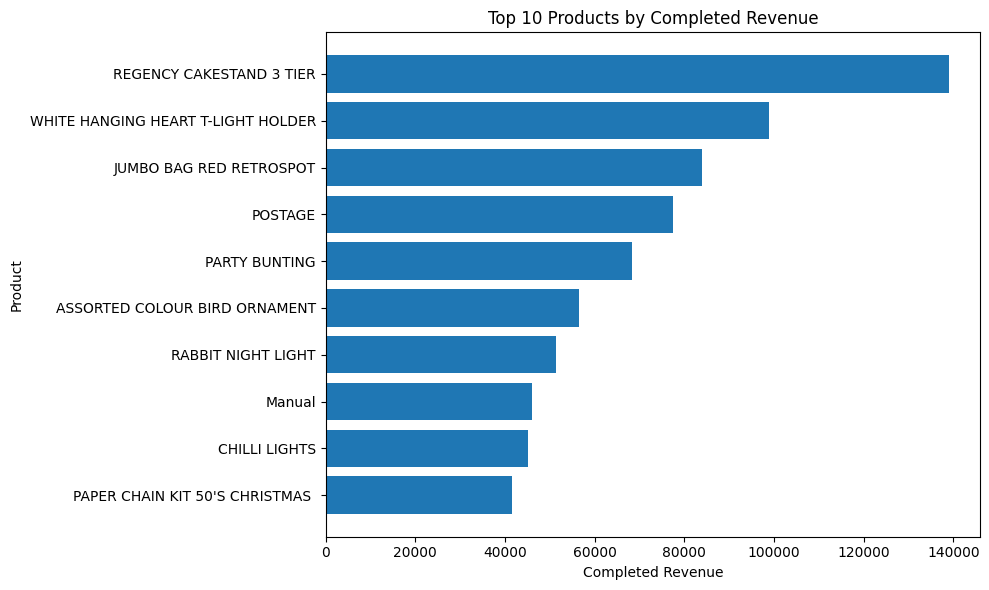

In [44]:
product_revenue_path = PROJECT_ROOT / "tableau_data/product_revenue.csv"

if product_revenue_path.exists():
    product_revenue = pd.read_csv(product_revenue_path)
    display(product_revenue.head(10))

    top_products = product_revenue.head(10)
    plt.figure(figsize=(10, 6))
    plt.barh(top_products["Description"].astype(str), top_products["CompletedRevenue"])
    plt.title("Top 10 Products by Completed Revenue")
    plt.xlabel("Completed Revenue")
    plt.ylabel("Product")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print("product_revenue.csv not found. Run the pipeline first.")

## Customer Segmentation

Customer segmentation was included because sales totals do not explain the different types of customers behind the revenue.

Customers were grouped into statuses such as:

- VIP
- Loyal
- Risk
- New
- Inactive

These groups were based on behaviour features including frequency, recency, monetary value, and average order value.

This makes the analysis more useful from a business point of view. For example, VIP customers could receive loyalty rewards, loyal customers could receive coupons, risk customers could receive re-engagement offers, new customers could receive welcome deals, and inactive customers could receive comeback campaigns.

In [45]:
customer_data_path = PROJECT_ROOT / "customer_order_sales_data.csv"

if customer_data_path.exists():
    customer_data = pd.read_csv(customer_data_path)
    display(customer_data.head())

    print("Customer data shape:", customer_data.shape)

    if "Customer_Status" in customer_data.columns:
        display(customer_data["Customer_Status"].value_counts())
    else:
        print("Customer_Status column not found. Run k-means_clustering.py first.")
else:
    print("customer_order_sales_data.csv not found. Run the pipeline first.")

,CustomerID,Frequency,Recency,MonetaryValue,AverageOrderValue,TotalQuantity,Customer_Status
0,12347,7,2,4310.00,615.71,2458,VIP
1,12348,4,75,1797.24,449.31,2341,Inactive
2,12349,1,19,1757.55,1757.55,631,Inactive
3,12350,1,310,334.40,334.40,197,Inactive
4,12352,7,36,2385.71,340.82,473,Risk


Customer data shape: (4327, 7)


Customer_Status
Inactive    2723
New          504
Risk         482
Loyal        422
VIP          196
Name: count, dtype: int64

## Customer Feature Statistics

The customer feature statistics help show how customer behaviour differs across the dataset.

Features such as `Frequency`, `Recency`, `MonetaryValue`, and `AverageOrderValue` were used because they describe how often customers buy, how recently they bought, how much they spent, and their average order value.

In [46]:
if customer_data_path.exists():
    numeric_customer_features = [
        "Frequency",
        "Recency",
        "MonetaryValue",
        "AverageOrderValue",
        "TotalQuantity"
    ]

    available_features = [col for col in numeric_customer_features if col in customer_data.columns]

    if available_features:
        display(customer_data[available_features].describe())
    else:
        print("Expected customer feature columns not found.")
else:
    print("customer_order_sales_data.csv not found. Run the pipeline first.")

,Frequency,Recency,MonetaryValue,AverageOrderValue,TotalQuantity
count,4327.000000,4327.000000,4327.000000,4327.000000,4327.000000
mean,4.248671,92.667437,1974.584287,379.572135,1148.720129
std,7.616933,100.141719,8469.773764,459.909213,4738.668459
min,1.000000,1.000000,2.900000,2.900000,1.000000
25%,1.000000,18.000000,307.430000,178.560000,160.000000
50%,2.000000,51.000000,668.580000,294.420000,378.000000
75%,5.000000,143.000000,1653.865000,430.600000,983.000000
max,204.000000,374.000000,280206.020000,14844.770000,196915.000000


## Customer Status Visualisation

This chart shows the number of customers in each customer status group.

It helps check whether the segmentation created usable groups and whether one group dominates the dataset.

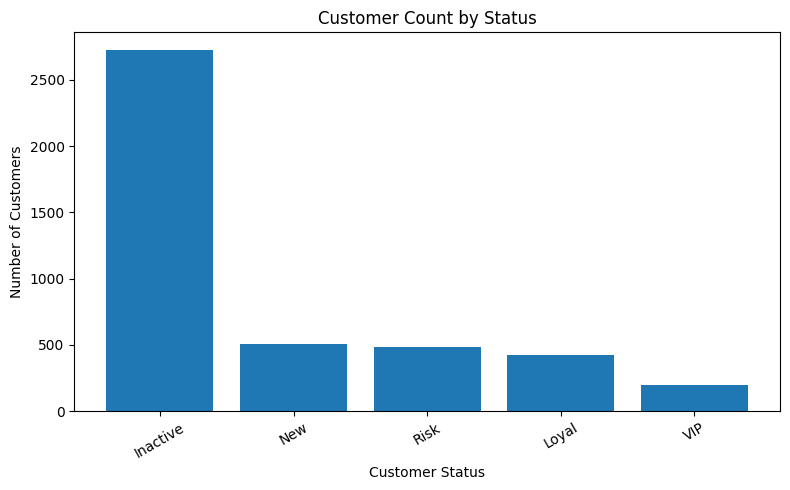

In [47]:
if customer_data_path.exists():
    if "Customer_Status" in customer_data.columns:
        status_counts = customer_data["Customer_Status"].value_counts()

        plt.figure(figsize=(8, 5))
        plt.bar(status_counts.index.astype(str), status_counts.values)
        plt.title("Customer Count by Status")
        plt.xlabel("Customer Status")
        plt.ylabel("Number of Customers")
        plt.xticks(rotation=30)
        plt.tight_layout()
        plt.show()
    else:
        print("Customer_Status column not found. Run k-means_clustering.py first.")
else:
    print("customer_order_sales_data.csv not found. Run the pipeline first.")

## K-Means Clustering Reflection

K-Means clustering was tested as an unsupervised learning method.

The model used:

- Frequency
- Recency
- AverageOrderValue
- MonetaryValue

The data was scaled using `StandardScaler` because K-Means is sensitive to different feature sizes.

K-Means was not treated as the final source of truth. It was used as a comparison method to see whether mathematical clusters matched the business-defined customer groups.

This was useful because business groups and machine-generated clusters do not always match perfectly. A customer segment can make sense for business decisions even if an unsupervised model groups customers differently.

## Regression Model

The regression model was used to test whether previous customer behaviour could help predict future order value.

The target variable was `OrderValue`.

The final model used previous customer behaviour such as:

- PreviousAverageOrderValue
- PreviousMonetaryValue
- PreviousOrderCount
- PreviousOrderValue
- DaysSincePreviousOrder
- Country

This was done because the model should only use information that would be available before the current order.

The final model had limited predictive power, but it was still useful because it showed that previous customer behaviour alone was not enough to accurately predict future order value.

In [48]:
regression_metrics_path = PROJECT_ROOT / "tableau_data/regression_metrics.csv"

if regression_metrics_path.exists():
    regression_metrics = pd.read_csv(regression_metrics_path)
    display(regression_metrics)
else:
    print("regression_metrics.csv not found. Run regression_model.py first.")

,Metric,Value
0,Mean Absolute Error,335.70
1,Mean Squared Error,1328666.84
2,Root Mean Squared Error,1152.68
3,R2 Score,0.24


## Regression Predictions

The actual vs predicted output helps show how well the regression model performed.

The model predicted smaller order values better than very large orders. This suggests that more features would be needed for stronger future predictions, such as product category, seasonality, promotions, or customer segment.

,ActualOrderValue,PredictedOrderValue,PredictionError,AbsoluteError
0,300.71,325.44,-24.73,24.73
1,119.05,181.40,-62.35,62.35
2,440.64,585.06,-144.42,144.42
3,269.17,371.72,-102.56,102.56
4,137.14,194.01,-56.87,56.87


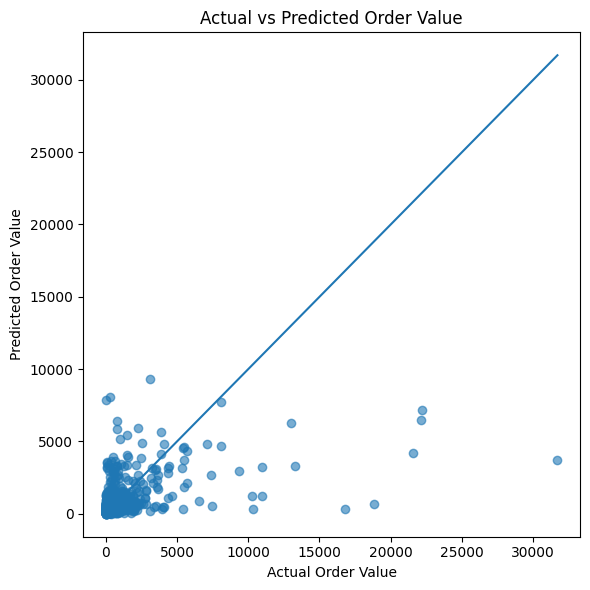

In [49]:
regression_predictions_path = PROJECT_ROOT / "tableau_data/regression_predictions.csv"

if regression_predictions_path.exists():
    regression_predictions = pd.read_csv(regression_predictions_path)
    display(regression_predictions.head())

    plt.figure(figsize=(6, 6))
    plt.scatter(regression_predictions["ActualOrderValue"], regression_predictions["PredictedOrderValue"], alpha=0.6)

    min_value = min(
        regression_predictions["ActualOrderValue"].min(),
        regression_predictions["PredictedOrderValue"].min()
    )

    max_value = max(
        regression_predictions["ActualOrderValue"].max(),
        regression_predictions["PredictedOrderValue"].max()
    )

    plt.plot([min_value, max_value], [min_value, max_value])
    plt.title("Actual vs Predicted Order Value")
    plt.xlabel("Actual Order Value")
    plt.ylabel("Predicted Order Value")
    plt.tight_layout()
    plt.show()
else:
    print("regression_predictions.csv not found. Run regression_model.py first.")

## Data Leakage Reflection

An earlier regression model produced a very high R² score.

After checking the data, this result was rejected because the dataset still contained product-level duplicate rows from the same invoice. Since multiple rows could share the same `InvoiceNo` and `OrderValue`, the model was likely learning repeated invoice information instead of genuinely predicting future order value.

To fix this, the regression dataset was rebuilt so that each invoice appeared only once.

This produced a lower score, but it was more honest and reliable.

This was an important learning point because a strong-looking model score is not always trustworthy. The data used to train the model must be checked carefully.

## Ethics, Privacy and GDPR

The dataset uses anonymous customer IDs instead of customer names, addresses, phone numbers, or email addresses.

Even though the dataset does not contain direct personal information, customer transaction data can still be sensitive because it shows purchasing behaviour.

Ethical considerations included:

- treating `CustomerID` as an anonymous identifier
- avoiding any attempt to identify individual customers
- being careful when interpreting customer groups
- avoiding unfair assumptions based only on spending behaviour
- presenting model results honestly
- explaining limitations clearly

If this project were used in a real business, GDPR and data governance rules would need to be followed. This would include secure storage, controlled access, data minimisation, clear retention rules, and transparency around how customer data is used.

## AI Assistance Used

AI assistance was used as a support tool during the project.

It helped with:

- debugging Python errors
- understanding Pandas issues
- planning the Streamlit layout
- explaining machine learning results
- identifying possible data leakage in regression
- improving README structure
- writing clearer dashboard insights
- reflecting on limitations and future improvements

AI was not used as a replacement for understanding the project. The code was tested, changed, reviewed, and adapted during development. Final decisions about the cleaning logic, analysis direction, model interpretation, and dashboard design were made by the developer.

## Limitations

This project has several limitations:

- The dataset covers a limited time period.
- Some rows had missing `CustomerID` values and had to be removed.
- Product descriptions were not always clean or standardised.
- The United Kingdom dominated the dataset, which affected country comparisons.
- The final month appeared incomplete and was excluded from the growth comparison.
- The regression model had limited predictive power.
- High-value orders were difficult for the model to predict.
- K-Means clusters did not perfectly match business-defined customer groups.
- Tableau Public embeds created some layout limitations inside Streamlit.
- The project used static CSV files rather than a live database.

These limitations are important because they show that the results should be interpreted carefully.

## Future Improvements

Future improvements could include:

- adding product category analysis
- improving product description cleaning
- testing more machine learning models
- adding customer churn prediction
- adding seasonality and promotional features
- creating a live database instead of static CSV files
- automating data refresh
- deploying the Streamlit dashboard online
- improving Tableau embed formatting
- adding authentication for business users

## Conclusion

This project turned raw retail transaction data into a structured analytics dashboard.

The project showed that completed revenue increased strongly over the analysed period, cancellations reduced revenue but did not stop the overall positive trend, and customer groups could help support business decisions around retention and marketing.

The regression model showed that previous customer behaviour had some relationship with future order value, but more features would be needed for stronger predictions.

Overall, the project demonstrates data cleaning, feature engineering, sales analysis, customer segmentation, machine learning, Tableau visualisation, Streamlit dashboard development, and reflection on limitations and ethical data use.

## Optional: Launch the Streamlit Dashboard

Streamlit is usually better launched from the terminal because it keeps running until stopped.

Use:

```bash
streamlit run streamlit_gui.py
```

If the Streamlit file is inside a folder, use the correct relative path, for example:

```bash
streamlit run Streamlit/streamlit_gui.py
```